In [ ]:
import torch 
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

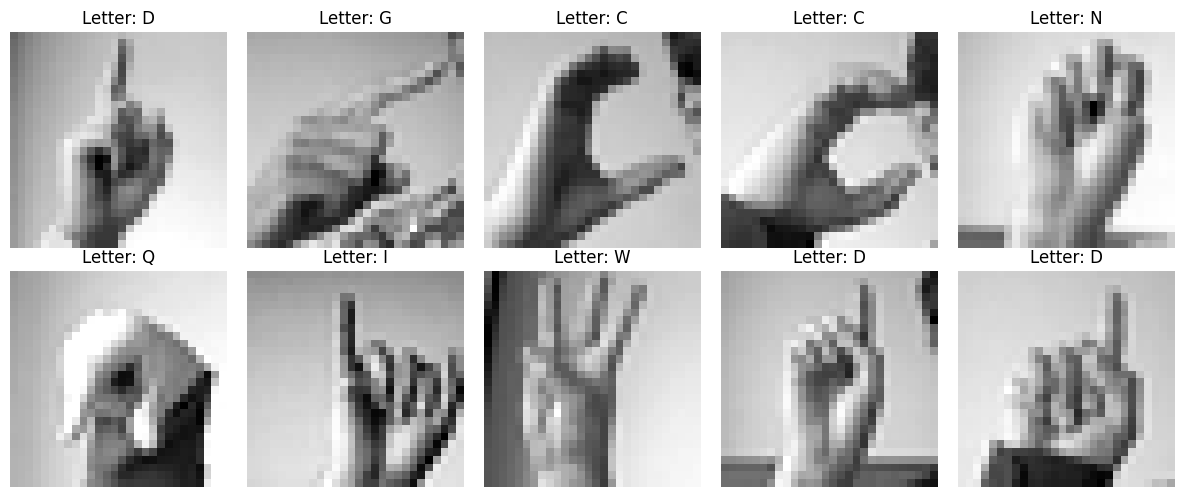

In [44]:
train = pd.read_csv("data/sign_mnist_train/sign_mnist_train.csv")


alphabet = 'ABCDEFGHIKLMNOPQRSTUVWXY'
label_map = {i: alphabet[i] if i < 9 else alphabet[i-1] for i in range(25) if i != 9}

# Function to show images
def show_images(data, labels, num_images=10):
    plt.figure(figsize=(12, 5))
    for i in range(num_images):
        plt.subplot(2, 5, i+1)
        # Reshape the 784 pixels to 28x28
        img = data.iloc[i].values.reshape(28, 28)
        plt.imshow(img, cmap='gray')
        plt.title(f"Letter: {label_map[labels.iloc[i]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize the first 10 images
show_images(train.drop('label', axis=1), train['label'])




### Transformer 
1. Split the data into patches
2. Linear project and positional embeddings
3. Small data (augment data)
4. CLS token (Classification token)

In [73]:
# Extract images as numpy array
train_images = train.drop('label', axis=1).values.reshape(-1, 28, 28)

import numpy as np

def extract_patches(images, patch_size=7):
    """
    images: Numpy array of shape (N, 28, 28)
    returns: Numpy array of shape (N, num_patches, patch_area)
    """
    n_samples = images.shape[0]
    img_size = images.shape[1]
    n_patches = (img_size // patch_size) ** 2
    patch_dim = patch_size * patch_size
    
    # Reshape into (N, 4, 7, 4, 7) to isolate the patches
    patches = images.reshape(
        n_samples, 
        img_size // patch_size, patch_size, 
        img_size // patch_size, patch_size
    )
    
    # Transpose to get (N, 4, 4, 7, 7) and then flatten to (N, 16, 49)
    patches = patches.transpose(0, 1, 3, 2, 4).reshape(n_samples, n_patches, patch_dim)
    
    return patches


X_patches = extract_patches(train_images) 
print(X_patches.shape)

# Trun X_patches into a tensor
X_patches_tensor = torch.tensor(X_patches, dtype=torch.float32)
print(X_patches_tensor.shape)

(27455, 16, 49)
torch.Size([27455, 16, 49])


In [88]:
# Convert labels to 0-23 range
# If label > 9, subtract 1 to fill the gap left by 'J'
y_train = train['label'].values
y_train_adjusted = np.array([label if label < 9 else label - 1 for label in y_train])

# Convert to Tensors
y_train_tensor = torch.LongTensor(y_train_adjusted)

In [92]:
class SignLanguageViT(nn.Module):
    def __init__(self, embed_dim=64, n_heads=4, n_layers=3, patch_dim=49, n_patches=16, num_classes=24):
        super().__init__()
        self.embed_dim = embed_dim
        
        # Step 1: Linear Projection
        self.projection = nn.Linear(patch_dim, embed_dim)
        
        # Step 2: Learnable Tokens & Embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embeddings = nn.Parameter(torch.randn(1, n_patches + 1, embed_dim))
        
        # Step 3: Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=128, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Step 4: Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]
        
        # Project patches
        x = self.projection(x) # (batch, 16, 64)
        
        # Add CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) # (batch, 17, 64)
        
        # Add Position info
        x = x + self.pos_embeddings
        
        # Pass through Transformer
        x = self.transformer_encoder(x)
        
        # Take the CLS token output and classify
        return self.classifier(x[:, 0, :])

# Initialize the model
model = SignLanguageViT()

In [107]:
def train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        total_train_loss = 0
        correct_train = 0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # Forward pass
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == batch_y).sum().item()
            
        avg_train_loss = total_train_loss / len(train_loader)
        train_acc = correct_train / len(train_loader.dataset)
        
        # --- EVALUATION PHASE ---
        model.eval()
        total_test_loss = 0
        correct_test = 0
        
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                loss = criterion(logits, batch_y)
                
                total_test_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct_test += (preds == batch_y).sum().item()
                
        avg_test_loss = total_test_loss / len(test_loader)
        test_acc = correct_test / len(test_loader.dataset)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.2%}")
        print(f"               | Test Loss:  {avg_test_loss:.4f} Acc: {test_acc:.2%}")

    print("\nTraining Complete!")

In [108]:
from torch.utils.data import DataLoader, TensorDataset

# Assuming X_train_patches and X_test_patches are (N, 16, 49) 
# and y_train/y_test are the adjusted labels (0-23)
train_ds = TensorDataset(X_patches_tensor, y_train_tensor)
test_ds = TensorDataset(X_patches_tensor, y_train_tensor)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)


# Initialize the class-based model we defined earlier
vit_model = SignLanguageViT(embed_dim=64, n_heads=4, n_layers=3)

# Start training
train_and_evaluate(vit_model, train_loader, test_loader, epochs=15)

Epoch [1/15] | Train Loss: 3.1812 Acc: 4.23%
               | Test Loss:  3.1768 Acc: 4.23%
Epoch [2/15] | Train Loss: 3.1468 Acc: 5.27%
               | Test Loss:  3.1069 Acc: 7.61%
Epoch [3/15] | Train Loss: 2.8954 Acc: 10.09%
               | Test Loss:  2.8064 Acc: 12.57%
Epoch [4/15] | Train Loss: 2.5458 Acc: 19.52%
               | Test Loss:  2.3034 Acc: 27.19%
Epoch [5/15] | Train Loss: 2.0177 Acc: 34.23%
               | Test Loss:  1.5775 Acc: 47.36%
Epoch [6/15] | Train Loss: 1.5614 Acc: 47.35%
               | Test Loss:  1.3812 Acc: 52.26%
Epoch [7/15] | Train Loss: 1.5846 Acc: 46.91%
               | Test Loss:  1.0921 Acc: 62.67%
Epoch [8/15] | Train Loss: 1.1657 Acc: 59.75%
               | Test Loss:  0.6938 Acc: 76.87%
Epoch [9/15] | Train Loss: 0.8887 Acc: 68.84%
               | Test Loss:  0.4719 Acc: 84.43%
Epoch [10/15] | Train Loss: 0.6490 Acc: 77.60%
               | Test Loss:  0.2763 Acc: 91.62%
Epoch [11/15] | Train Loss: 0.5430 Acc: 81.18%
               |

In [109]:
import cv2
import torch
import numpy as np

def predict_sign(image_path, model):
    # 1. Load and Preprocess to match MNIST format
    # Read as grayscale and resize to 28x28
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28, 28))
    
    # Normalize (0-1)
    img = img / 255.0
    
    # 2. Transform to Patches (our 16 x 49 format)
    # We use the same logic we used for training
    patches = img.reshape(4, 7, 4, 7).transpose(0, 2, 1, 3).reshape(1, 16, 49)
    patch_tensor = torch.FloatTensor(patches)
    
    # 3. Inference
    model.eval()
    with torch.no_grad():
        logits = model(patch_tensor)
        prediction_idx = torch.argmax(logits, dim=1).item()
    
    # 4. Map back to Alphabet
    # Accounting for the 'J' gap (0-23 -> A-Y)
    alphabet = 'ABCDEFGHIKLMNOPQRSTUVWXY'
    return alphabet[prediction_idx]

# Usage:
# result = predict_sign('my_hand_gesture.jpg', vit_model)
# print(f"The model thinks this is the letter: {result}")

In [114]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare for Evaluation
model.eval() # Turns off dropout for consistent results
all_preds = []
all_labels = []

# 2. Map indices back to Alphabet (skipping J at index 9)
alphabet = 'ABCDEFGHIKLMNOPQRSTUVWXY'

with torch.no_grad(): # No gradients needed for output, saves memory
    for batch_x, batch_y in test_loader:
        # Get model output
        logits = model(batch_x)
        
        # Get the index of the highest value
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.numpy())
        all_labels.extend(batch_y.numpy())

# 3. Calculate Final Accuracy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
accuracy = (all_preds == all_labels).mean()

print(f"--- Model Evaluation ---")
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

--- Model Evaluation ---
Final Test Accuracy: 4.00%


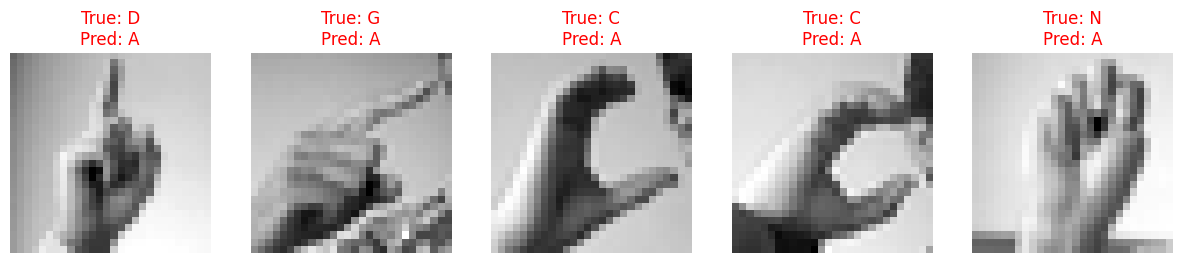

In [125]:
def plot_results(images, labels, preds, n=5):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        # Reshape the flattened 784 pixels back to 28x28 for viewing
        img = images[i].reshape(28, 28)
        plt.imshow(img, cmap='gray')
        
        true_letter = alphabet[labels[i]]
        pred_letter = alphabet[preds[i]]
        
        color = 'green' if true_letter == pred_letter else 'red'
        plt.title(f"True: {true_letter}\nPred: {pred_letter}", color=color)
        plt.axis('off')
    plt.show()

# Assuming X_test contains your original 28x28 images or flat 784 arrays
plot_results(train_images, all_labels, all_preds)